/tmp/ipykernel_2977863/1161827170.py:5: UserWarning: Input line 2 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  names = np.loadtxt(


['SLACSJ0029-0055' 'BELLSJ0830+5116']


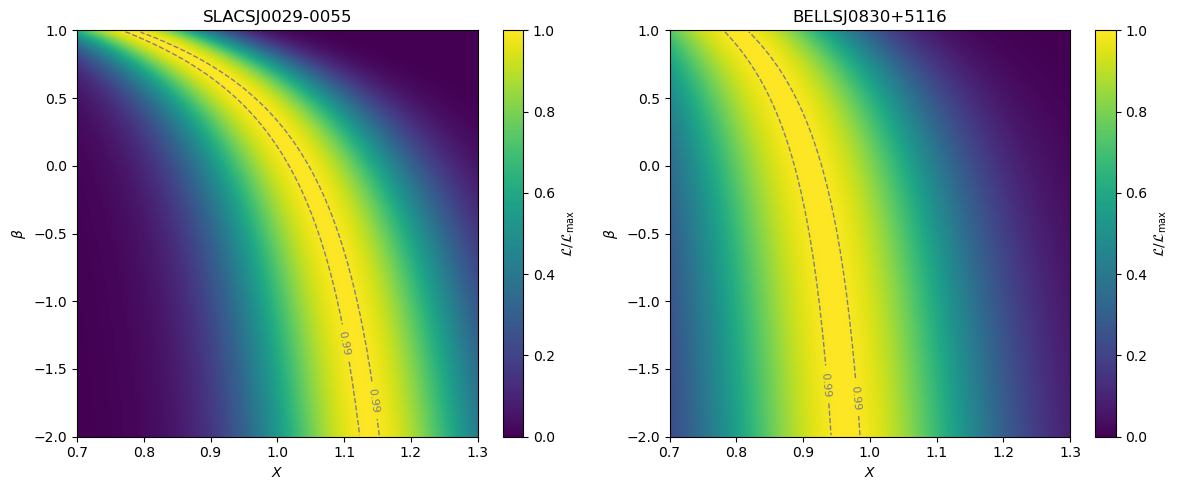

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

names = np.loadtxt(
    "../../data/obs125_krms_vbias_kenv.dat",
    comments="#",
    skiprows=1,
    usecols=0,
    dtype=str
)

lens_ids = [1, 105] #60,105,115
print(names[lens_ids])

def to_edges(coord, n_expected):
    """
    Convert coordinate centers to bin edges.
    If the input already has length n_expected + 1, return it directly.
    """
    coord = np.asarray(coord).ravel()

    if coord.size == n_expected + 1:
        return coord

    elif coord.size == n_expected:
        # Infer edges from neighboring coordinate centers
        diffs = np.diff(coord)

        if not np.all(np.isfinite(diffs)) or np.any(diffs == 0):
            # Fall back to a uniform-step estimate if coordinates are abnormal
            step = (coord[-1] - coord[0]) / (n_expected - 1) if n_expected > 1 else 1.0
            edges = np.concatenate([
                [coord[0] - 0.5 * step],
                (coord[:-1] + coord[1:]) / 2.0,
                [coord[-1] + 0.5 * step]
            ])
            return edges

        # Use midpoints as inner edges and linearly extrapolate boundary edges
        inner = (coord[:-1] + coord[1:]) / 2.0
        left_edge = coord[0] - (inner[0] - coord[0])
        right_edge = coord[-1] + (coord[-1] - inner[-1])
        edges = np.concatenate([[left_edge], inner, [right_edge]])
        return edges

    else:
        raise ValueError(f"Coordinate length ({coord.size}) does not match data dimension ({n_expected}).")


def load_lens_data(lens_id):
    """
    Load likelihood data and coordinate grids for one lens.
    """
    fname = "../../data/xbeta_likelihood_maps/" + names[lens_id] + ".fits"

    with fits.open(fname) as hdul:
        data = hdul[0].data
        x = np.asarray(hdul[1].data).ravel()
        y = np.asarray(hdul[2].data).ravel()

    ny, nx = data.shape

    if not ((x.ndim == 1) and (y.ndim == 1)):
        raise ValueError("x/y coordinates should be one-dimensional arrays.")

    x_edges = to_edges(x, nx)
    y_edges = to_edges(y, ny)

    return data, x, y, x_edges, y_edges


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for ax, lens_id in zip(axes, lens_ids):
    data, x, y, x_edges, y_edges = load_lens_data(lens_id)

    # Normalize the likelihood by its maximum value
    data_norm = data / np.nanmax(data)

    # pcm = ax.pcolormesh(
    #     x_edges,
    #     y_edges,
    #     data_norm,
    #     shading="auto",
    #     cmap="viridis",
    #     vmin=0,
    #     vmax=1
    # )
    pcm = ax.imshow(
    data_norm,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    interpolation="bilinear",
    rasterized=True
)

    # Draw a dashed contour line close to the likelihood peak
    peak_level = 0.99
    cs = ax.contour(
        x,
        y,
        data_norm,
        levels=[peak_level],
        colors="grey",
        linestyles="--",
        linewidths=1.
    )

    # Label the dashed contour
    ax.clabel(
        cs,
        inline=True,
        fontsize=8,
        fmt={peak_level: r"$0.99$"}
    )

    ax.set_xlabel(r"$X$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(names[lens_id])

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"$\mathcal{L}/\mathcal{L}_{\max}$")

plt.tight_layout()
plt.savefig('img_xbeta_2.pdf', dpi=400, bbox_inches='tight')
#plt.savefig('img_xbeta_2.png', dpi=400, bbox_inches='tight')
plt.show()